# pred-3: fusing the two windows to name the author

The companion notebook fused how a person emails with what they discuss to read
their rank. This one points the same idea at identity: given one message, can the
two windows name who wrote it, and does fusing them beat either alone?

The two windows are rebuilt at the message level. The content window is the body
text, turned into word and character TF-IDF features, what a person writes and how
they spell, space and punctuate it. The metadata window is the envelope of the one
message, how it was sent: how many recipients and carbon copies, whether anyone
outside Enron was on it, the length, the hour, where it sits in its thread. Nothing
that names the sender (the address, the mailbox, the folder owner) enters either
window. The target is the author, one of 110 people who wrote at least 120 keepable
messages; up to 600 messages per person go into the model, so the prolific do not
swamp the rest, and the score is reported both per message and averaged evenly over
the 110 authors. The split is by thread, so a test message never shares a thread,
or its quoted text and running signature, with one the model trained on.

In [1]:
from pathlib import Path
import re, collections, numpy as np, pandas as pd
from scipy import sparse
from scipy.stats import chi2
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from PIL import Image as _PILImage
from IPython.display import Image as _PNG, display as _show

def find_root() -> Path:
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "eda-5" / "clean" / "messages_clean.parquet").exists():
            return base
    raise FileNotFoundError("eda-5/clean not found above " + str(here))
ROOT = find_root()
CLEAN, REFS = ROOT / "eda-5" / "clean", ROOT / "eda-5" / "refs"
PLOTS = ROOT / "pred-3" / "plots"; PLOTS.mkdir(parents=True, exist_ok=True)

BLUE, RED, ORANGE, GREEN, GREY = "#3b6fb6", "#d04545", "#e08a3c", "#3a7d44", "#b8b8b8"
PURPLE, LBLUE = "#6a3d9a", "#8db4d8"
pio.templates["enron"] = go.layout.Template(layout=dict(
    font=dict(family="DejaVu Sans, Arial, sans-serif", size=16, color="#222222"),
    title=dict(font=dict(size=23), x=0.5, xanchor="center"),
    paper_bgcolor="white", plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True),
    yaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True)))
pio.templates.default = "enron"

def save_fig(fig, name, w=1100, h=560, margin=None):
    fig.update_layout(width=w, height=h, margin=margin or dict(l=90, r=70, t=80, b=80))
    out = PLOTS / name
    fig.write_image(out, scale=3)
    _PILImage.open(out).save(out, dpi=(300, 300))
    _show(_PNG(filename=str(out)))
    return fig

## Building the two windows at the message level

Both models are the same linear support-vector classifier, only the features
differ. The content side joins word one- and two-grams with character three- to
five-grams, the standard combination for authorship: words catch vocabulary and
turns of phrase, characters catch spelling, spacing and punctuation habits. A
second content model first redacts every owner's own name from the text, to
separate recognising a person's writing from reading their signature. The metadata
side is the nineteen-feature envelope, standardised. Each model is fit on the
training threads and scored on the held-out ones; the two are then blended by their
decision margins.

In [2]:
m = pd.read_parquet(CLEAN / "messages_clean.parquet")
roles = pd.read_parquet(CLEAN / "people_roles.parquet")
rcp = pd.read_parquet(CLEAN / "recipients_clean.parquet", columns=["message_id", "recipient_person"])
DEL = set(pd.read_csv(REFS / "assistant_delegates.csv", sep=";")["assistant_addr"])

au_all = m[m.sender_person.notna() & ~m.from_addr_norm.isin(DEL)
          & ~m.body_is_boilerplate & ~m.body_empty_after_clean & m.body.notna()].copy()
cnt = au_all.groupby("sender_person").size()
authors = sorted(cnt[cnt >= 120].index)
CAP = 600
idx = []
for a, gdf in au_all[au_all.sender_person.isin(authors)].groupby("sender_person"):
    idx.extend(gdf.sample(n=min(CAP, len(gdf)), random_state=0).index)
au = au_all.loc[idx].reset_index(drop=True)

# envelope features (per message; nothing that identifies the sender)
au["hour"] = au["date"].dt.hour.where(au["date_plausible"]).fillna(12)
au["dow"] = au["date"].dt.dayofweek.where(au["date_plausible"]).fillna(2)
au["weekend"] = (au["dow"] >= 5).astype(int)
au["subj_len"] = au["subject"].fillna("").str.len()
au["is_reply"] = (au["thread_position"] > 0).astype(int)
ENV = ["to_count", "cc_count", "recipient_count", "external_recipient_count", "has_external_recipient",
       "list_recipient_count", "has_list_recipient", "file_size", "body_chars", "body_was_trimmed",
       "is_thread_root", "thread_position", "thread_size", "in_sent", "hour", "dow", "weekend",
       "subj_len", "is_reply"]
Xenv = au[ENV].astype(float).fillna(0.0).values
for c in ["file_size", "body_chars", "thread_size", "subj_len"]:
    Xenv[:, ENV.index(c)] = np.log1p(Xenv[:, ENV.index(c)])
y = au["sender_person"].values
groups = au["thread_id"].values
NAME = roles.set_index("owner")["display_name"].to_dict()

# redact every owner's name (>=3 letters) from the body, for the name-free content model
nameset = frozenset(t for col in ["first_name", "last_name", "display_name"] for v in roles[col].dropna()
                    for t in re.findall(r"[a-z]{3,}", str(v).lower()))
TOK = re.compile(r"[A-Za-z]{3,}")
_redact = lambda mo: " " if mo.group().lower() in nameset else mo.group()
body = au["body"].values
body_red = np.array([TOK.sub(_redact, t) for t in body], dtype=object)

# one thread-grouped, author-stratified 80/20 split
tr, te = next(StratifiedGroupKFold(5, shuffle=True, random_state=0).split(au, y, groups))
print(f"{len(au)} messages, {len(authors)} authors, chance {1/len(authors):.3f}; train {len(tr)} test {len(te)}")

WORD = dict(lowercase=True, strip_accents="unicode", token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
            ngram_range=(1, 2), min_df=3, max_features=15000, sublinear_tf=True)
CHAR = dict(lowercase=True, strip_accents="unicode", analyzer="char_wb",
            ngram_range=(3, 4), min_df=5, max_features=20000, sublinear_tf=True)

def text_scores(text):                    # n_features > n_samples here, so the dual solver is the fast one
    w, c = TfidfVectorizer(**WORD), TfidfVectorizer(**CHAR)
    Xtr = sparse.hstack([w.fit_transform(text[tr]), c.fit_transform(text[tr])]).tocsr()
    Xte = sparse.hstack([w.transform(text[te]), c.transform(text[te])]).tocsr()
    clf = LinearSVC(C=1.0, dual=True, max_iter=2000).fit(Xtr, y[tr])
    return clf.decision_function(Xte), clf.classes_

# the three fits are the only slow step, so cache their outputs under work/ (re-runs reload in seconds)
import pickle
WORKDIR = ROOT / "pred-3" / "work"; WORKDIR.mkdir(parents=True, exist_ok=True)
sig = str((CAP, len(au), len(tr), WORD, CHAR))
cache = WORKDIR / "auth_scores.pkl"
blob = pickle.load(open(cache, "rb")) if cache.exists() else None
if blob and blob["sig"] == sig:
    Sc, Sn, Sm, classes, meta_coef = blob["data"]; print("loaded cached scores")
else:
    Sc, classes = text_scores(body)      # words, signatures included
    Sn, _ = text_scores(body_red)        # words, own name redacted
    scaler = StandardScaler().fit(Xenv[tr])   # n_samples > n_features here, so the primal solver is fast
    msvc = LinearSVC(C=1.0, dual=False, max_iter=2000).fit(scaler.transform(Xenv[tr]), y[tr])
    Sm = msvc.decision_function(scaler.transform(Xenv[te]))
    meta_coef = msvc.coef_
    pickle.dump({"sig": sig, "data": (Sc, Sn, Sm, classes, meta_coef)}, open(cache, "wb"))
yte = y[te]
def both(S):
    p = classes[S.argmax(1)]
    return accuracy_score(yte, p), balanced_accuracy_score(yte, p)
print("              micro  macro")
for tag, S in [("content", Sc), ("content(redacted)", Sn), ("metadata", Sm)]:
    mi, ma = both(S); print(f"  {tag:17s} {mi:.3f}  {ma:.3f}")

48063 messages, 110 authors, chance 0.009; train 38451 test 9612
loaded cached scores
              micro  macro
  content           0.675  0.640
  content(redacted) 0.568  0.529
  metadata          0.083  0.068


## How well each window names the author

fused best at w=1.6: micro 0.691 (content 0.675, gain +0.016); macro 0.652 vs 0.640


/tmp/ipykernel_1532944/4087767971.py:41: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


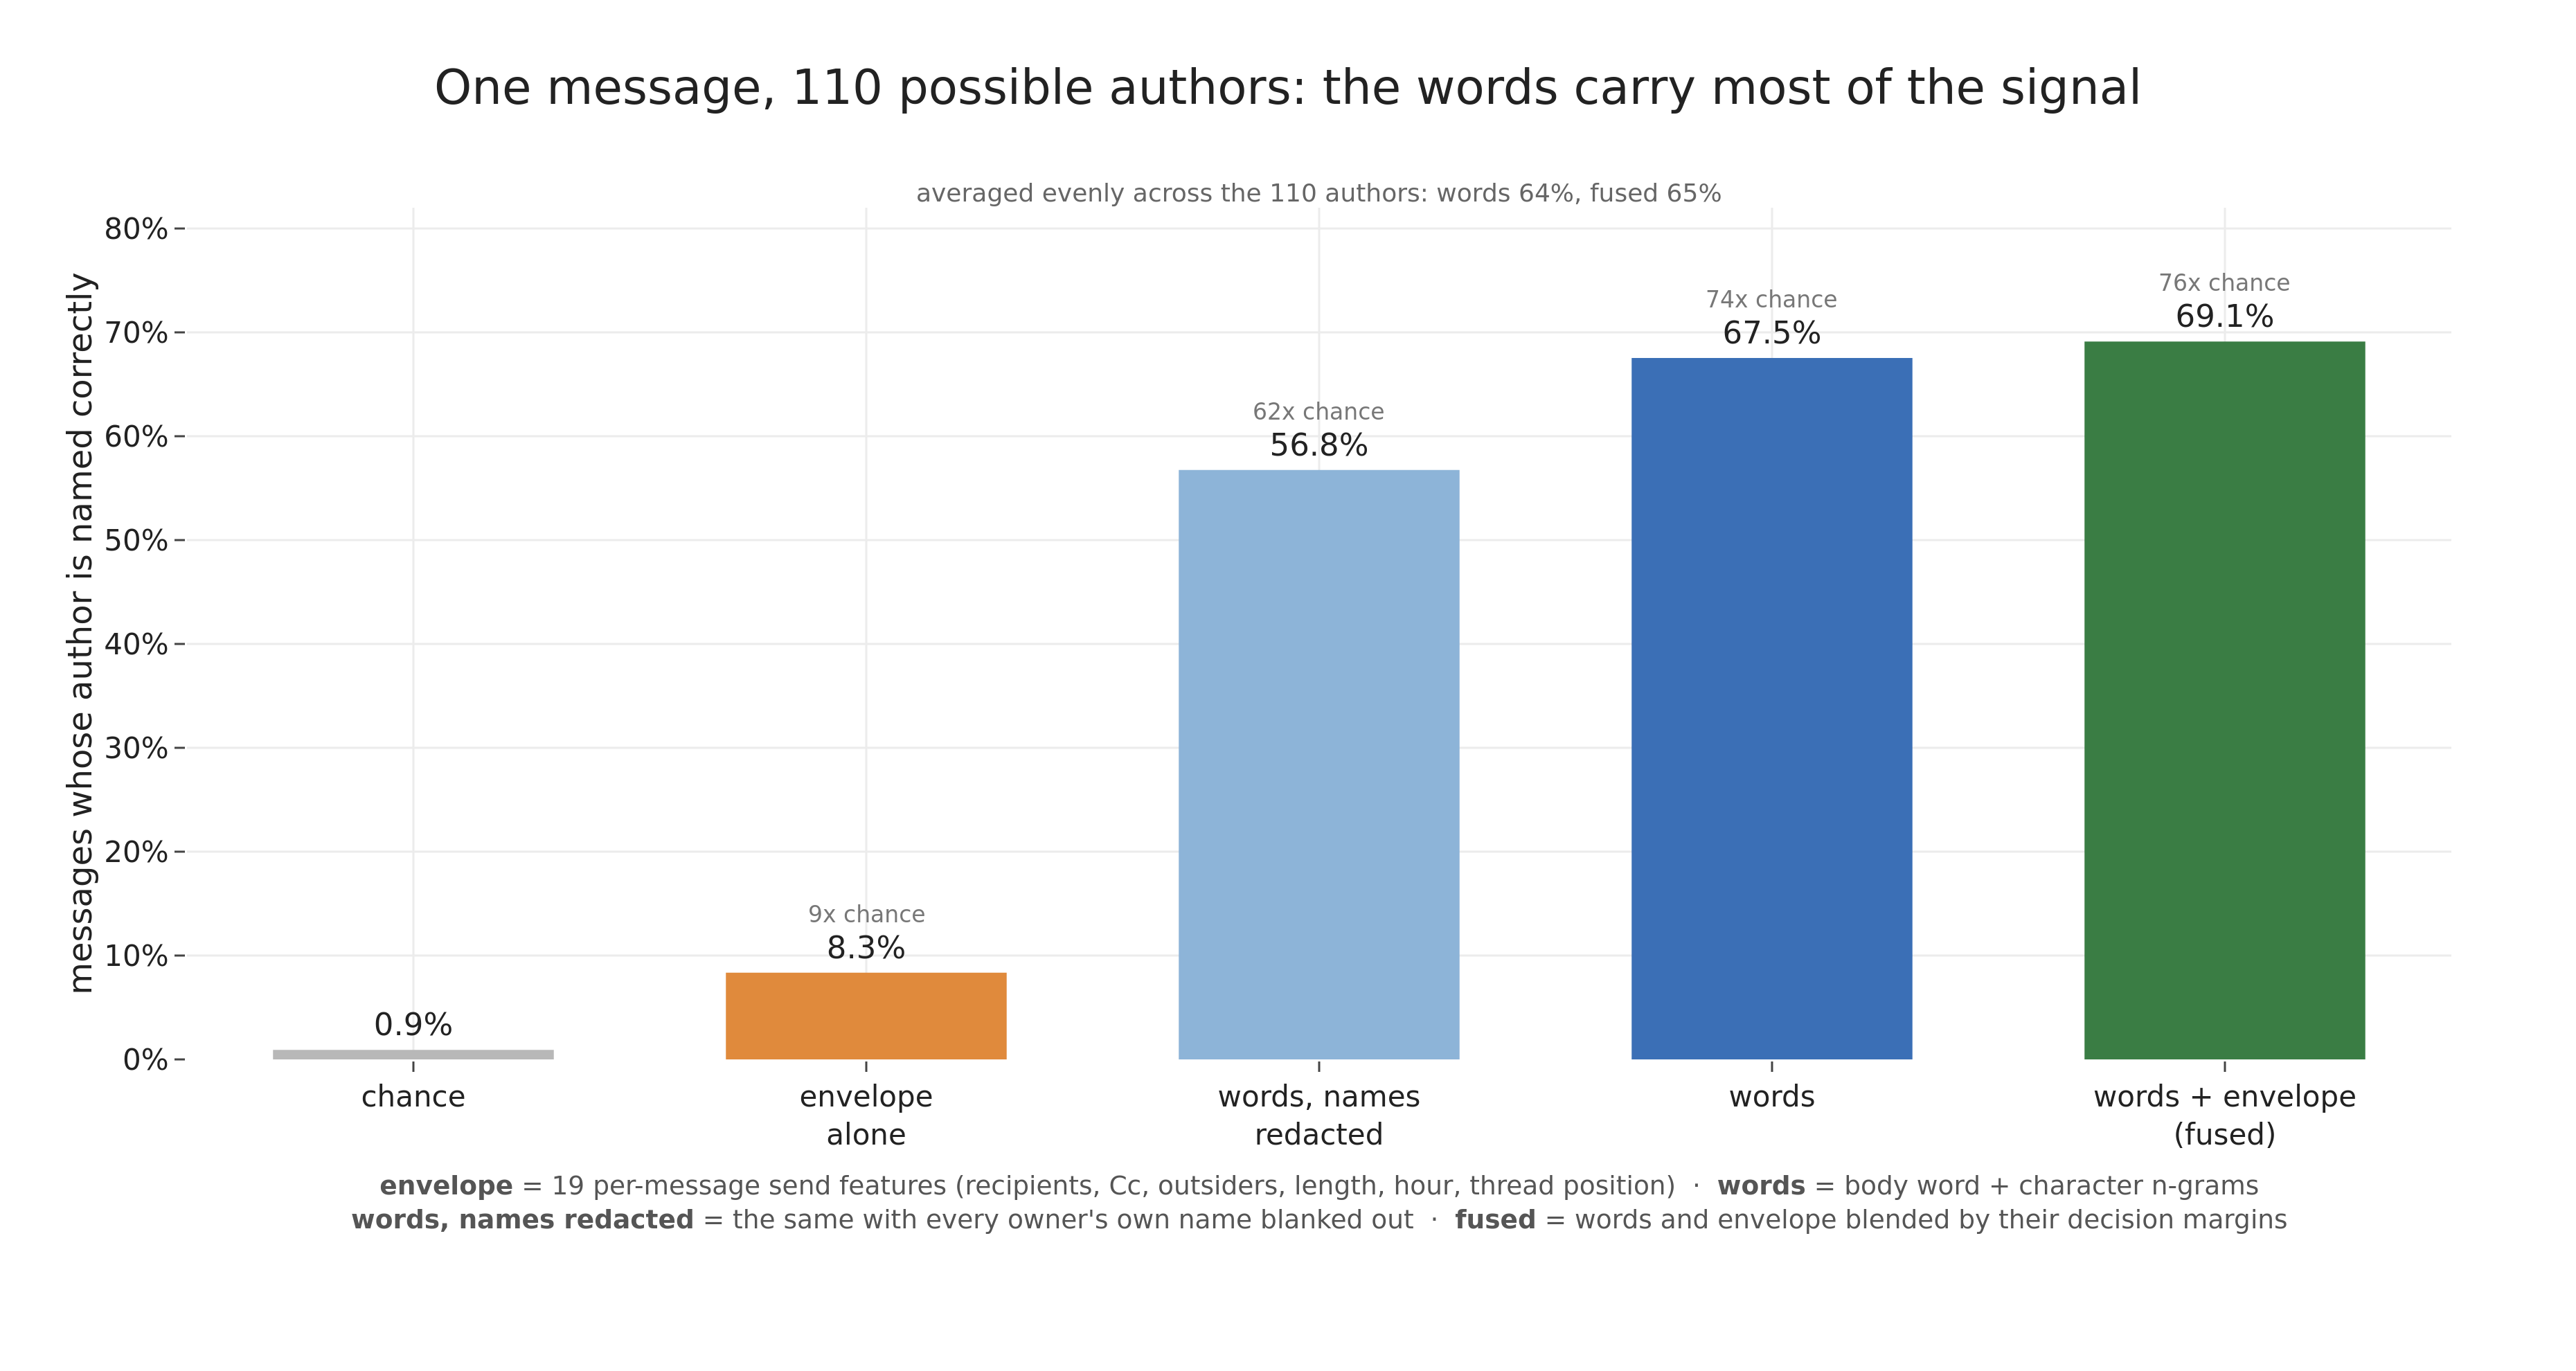

In [3]:
# late fusion: blend the two standardised decision-score matrices, sweep the weight on the envelope
zc = (Sc - Sc.mean()) / Sc.std()
zm = (Sm - Sm.mean()) / Sm.std()
ws = np.round(np.linspace(0, 2.0, 41), 3)
fus_mi = np.array([accuracy_score(yte, classes[(zc + w * zm).argmax(1)]) for w in ws])
fus_ma = np.array([balanced_accuracy_score(yte, classes[(zc + w * zm).argmax(1)]) for w in ws])
wbest = ws[int(fus_mi.argmax())]
pred_c = classes[Sc.argmax(1)]
pred_f = classes[(zc + wbest * zm).argmax(1)]
mi = lambda S: accuracy_score(yte, classes[S.argmax(1)])
ma = lambda S: balanced_accuracy_score(yte, classes[S.argmax(1)])
a_meta, a_red, a_con, a_fus = mi(Sm), mi(Sn), mi(Sc), fus_mi.max()
chance = 1 / len(classes)
print(f"fused best at w={wbest}: micro {a_fus:.3f} (content {a_con:.3f}, gain {a_fus-a_con:+.3f}); "
      f"macro {fus_ma.max():.3f} vs {ma(Sc):.3f}")

bars = [("chance", chance, GREY), ("envelope<br>alone", a_meta, ORANGE),
        ("words, names<br>redacted", a_red, LBLUE), ("words", a_con, BLUE),
        ("words + envelope<br>(fused)", a_fus, GREEN)]
fig = go.Figure(go.Bar(x=[b[0] for b in bars], y=[b[1] * 100 for b in bars],
    marker_color=[b[2] for b in bars], width=0.62,
    text=[f"{b[1]*100:.1f}%" for b in bars], textposition="outside", textfont=dict(size=15),
    cliponaxis=False, showlegend=False))
for b in bars:
    if b[1] > chance * 2:
        fig.add_annotation(x=b[0], y=b[1] * 100 + 5.5, text=f"{b[1]/chance:.0f}x chance",
            showarrow=False, font=dict(size=11, color="#777"))
fig.add_annotation(xref="paper", yref="paper", x=0.5, y=1.04, xanchor="center", showarrow=False,
    text=f"averaged evenly across the 110 authors: words {ma(Sc):.0%}, fused {fus_ma.max():.0%}",
    font=dict(size=12, color="#666"))
fig.add_annotation(xref="paper", yref="paper", x=0.5, y=-0.21, xanchor="center", align="center", showarrow=False,
    text="<b>envelope</b> = 19 per-message send features (recipients, Cc, outsiders, length, hour, thread position)"
         "&nbsp; · &nbsp;<b>words</b> = body word + character n-grams<br>"
         "<b>words, names redacted</b> = the same with every owner's own name blanked out"
         "&nbsp; · &nbsp;<b>fused</b> = words and envelope blended by their decision margins",
    font=dict(size=12.5, color="#555"))
fig.update_yaxes(title_text="messages whose author is named correctly", range=[0, 82], ticksuffix="%")
fig.update_layout(title="One message, 110 possible authors: the words carry most of the signal")
save_fig(fig, "a1_authorship_skill.png", w=1240, h=660, margin=dict(l=90, r=60, t=100, b=150))

The words name the author of about two messages in three out of more than a
hundred candidates, some seventy times chance, on a split where the model never saw
the same thread in training. Redacting every owner's own name from the text drops
that by roughly ten points, to the high fifties, so a name in the signature does
help, but most of the signal survives without it: the writing itself, the
vocabulary and the spelling and spacing habits the character n-grams catch. The
envelope on its own is weak, naming under a tenth of messages, which is expected,
since a single message's recipient count and hour say little about who sent it.
Averaged evenly across authors the figures fall a few points, because the lightest
writers are the hardest, but the ordering holds.

## What the envelope adds, and what it knows

gain +0.016  bootstrap [+0.012,+0.019]
McNemar: 253 fixed by fusion, 102 broken, p = 1.70e-15


/tmp/ipykernel_1532944/4087767971.py:41: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


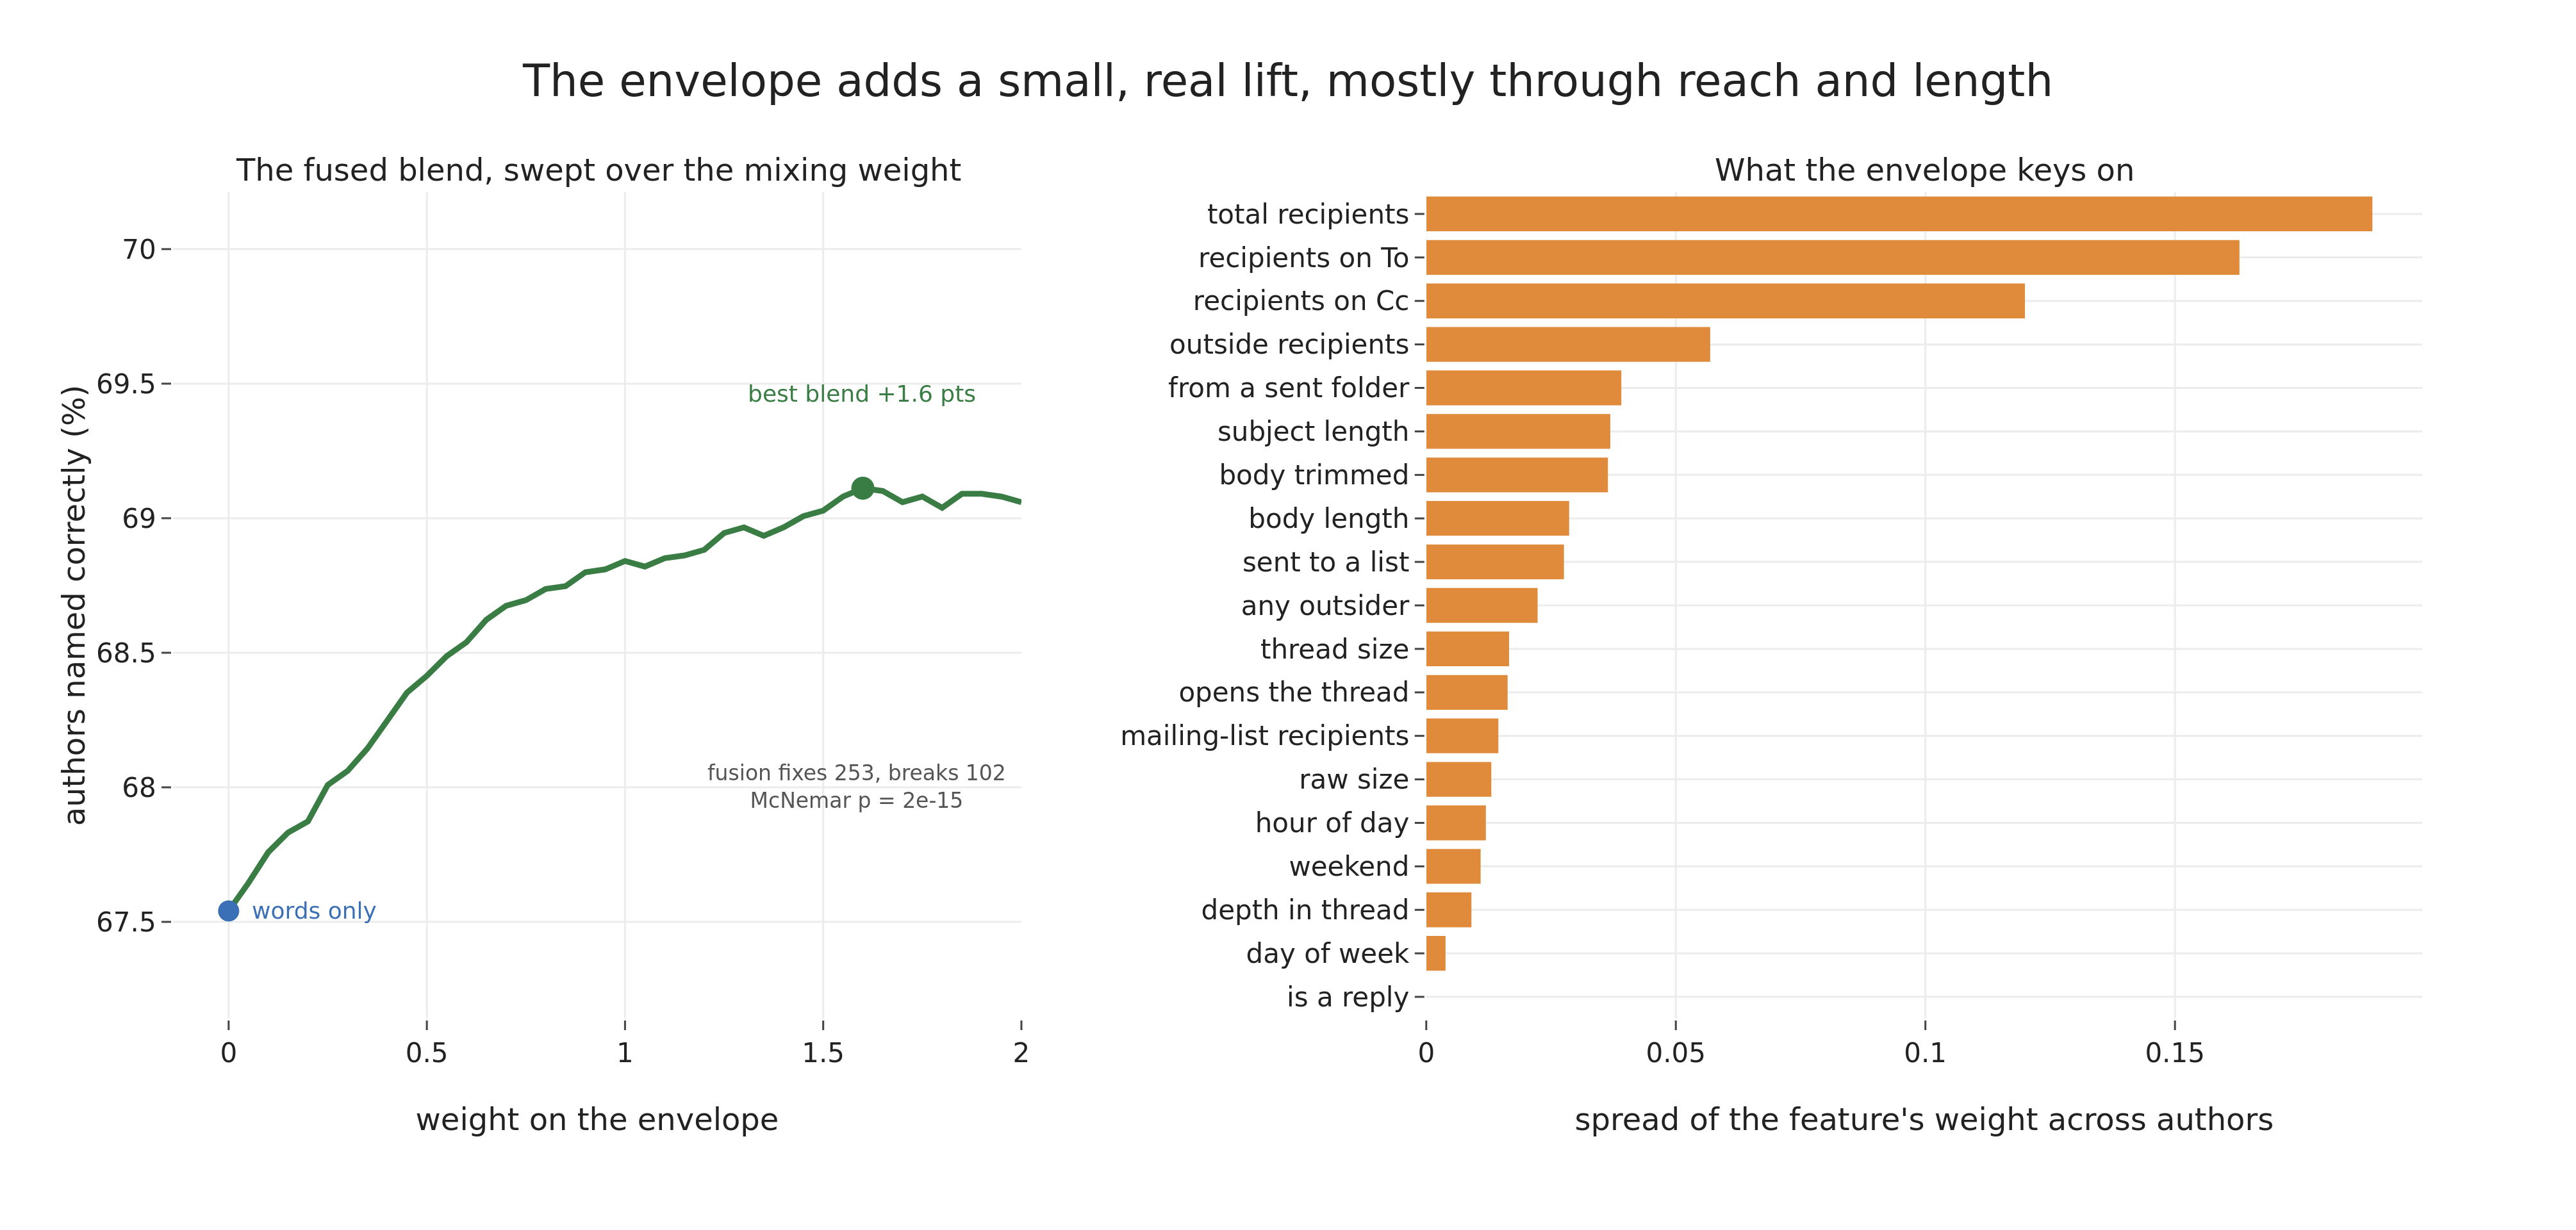

In [4]:
# is the fusion gain real? McNemar on paired correctness, and a bootstrap CI on the gain
cc, cf = (pred_c == yte), (pred_f == yte)
b, c = int(np.sum(cc & ~cf)), int(np.sum(~cc & cf))
mcn_p = float(chi2.sf((abs(b - c) - 1) ** 2 / (b + c), 1)) if (b + c) else 1.0
rng = np.random.default_rng(0)
boot = np.array([cf[s].mean() - cc[s].mean()
                 for s in (rng.integers(0, len(yte), len(yte)) for _ in range(1000))])
print(f"gain {a_fus-a_con:+.3f}  bootstrap [{np.percentile(boot,2.5):+.3f},{np.percentile(boot,97.5):+.3f}]")
print(f"McNemar: {c} fixed by fusion, {b} broken, p = {mcn_p:.2e}")

# which envelope features separate authors: spread of the weight across the 110 classes
imp = pd.Series(meta_coef.std(axis=0), index=ENV).sort_values()
EPRETTY = {"to_count": "recipients on To", "cc_count": "recipients on Cc", "recipient_count": "total recipients",
    "external_recipient_count": "outside recipients", "has_external_recipient": "any outsider",
    "list_recipient_count": "mailing-list recipients", "has_list_recipient": "sent to a list",
    "file_size": "raw size", "body_chars": "body length", "body_was_trimmed": "body trimmed",
    "is_thread_root": "opens the thread", "thread_position": "depth in thread", "thread_size": "thread size",
    "in_sent": "from a sent folder", "hour": "hour of day", "dow": "day of week", "weekend": "weekend",
    "subj_len": "subject length", "is_reply": "is a reply"}

fig = make_subplots(rows=1, cols=2, column_widths=[0.46, 0.54], horizontal_spacing=0.18,
    subplot_titles=["The fused blend, swept over the mixing weight", "What the envelope keys on"])
fig.add_trace(go.Scatter(x=ws, y=fus_mi * 100, mode="lines", line=dict(color=GREEN, width=3),
    showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(x=[0], y=[a_con * 100], mode="markers", marker=dict(color=BLUE, size=11),
    showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(x=[wbest], y=[a_fus * 100], mode="markers", marker=dict(color=GREEN, size=12),
    showlegend=False), row=1, col=1)
fig.add_annotation(x=0.05, y=a_con * 100, text="words only", showarrow=False, xanchor="left",
    font=dict(size=12, color=BLUE), row=1, col=1)
fig.add_annotation(x=wbest, y=a_fus * 100 + 0.35, text=f"best blend +{(a_fus-a_con)*100:.1f} pts",
    showarrow=False, font=dict(size=12, color=GREEN), row=1, col=1)
fig.add_annotation(x=1.97, y=68.0, xanchor="right", showarrow=False,
    text=f"fusion fixes {c}, breaks {b}<br>McNemar p = {mcn_p:.0e}",
    font=dict(size=11, color="#555"), row=1, col=1)
fig.update_xaxes(title_text="weight on the envelope", row=1, col=1)
fig.update_yaxes(title_text="authors named correctly (%)", range=[a_con * 100 - 0.4, a_fus * 100 + 1.1], row=1, col=1)
fig.add_trace(go.Bar(y=[EPRETTY[f] for f in imp.index], x=imp.values, orientation="h",
    marker_color=ORANGE, cliponaxis=False, showlegend=False), row=1, col=2)
fig.update_xaxes(title_text="spread of the feature's weight across authors", row=1, col=2)
fig.update_layout(title="The envelope adds a small, real lift, mostly through reach and length")
save_fig(fig, "a2_envelope_add.png", w=1340, h=640, margin=dict(l=90, r=80, t=100, b=110))

The lift is small but not luck. Blended at its best weight the envelope fixes
clearly more messages than it breaks, the bootstrap interval on the gain stays
above zero, and McNemar rejects chance comfortably. The curve climbs from the
words-only point, peaks when the envelope is given a modest weight, and falls once
the weak envelope is trusted too far. What the envelope keys on is reach and size:
how many people and outsiders a message went to, how long it was, how deep in its
thread it sits. Those are habits, a person tends to send to the same sort of
audience at the same sort of length, and they survive as a faint fingerprint
beneath the words.

## Who you get mistaken for

per-author accuracy: median 0.67, range 0.00-0.97
mix-ups landing on a correspondent: observed 39%, expected 23%
top confused pairs: [('Shelley Corman', 'Rod Hayslett', 16), ('Tracy Geaccone', 'Rod Hayslett', 13), ('John Griffith', 'Mike Maggi', 12), ('Mark Guzman', 'Matthew Lenhart', 8), ('Steven Kean', 'James Derrick', 8), ('Chris Stokley', 'Mike Maggi', 8)]


/tmp/ipykernel_1532944/4087767971.py:41: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


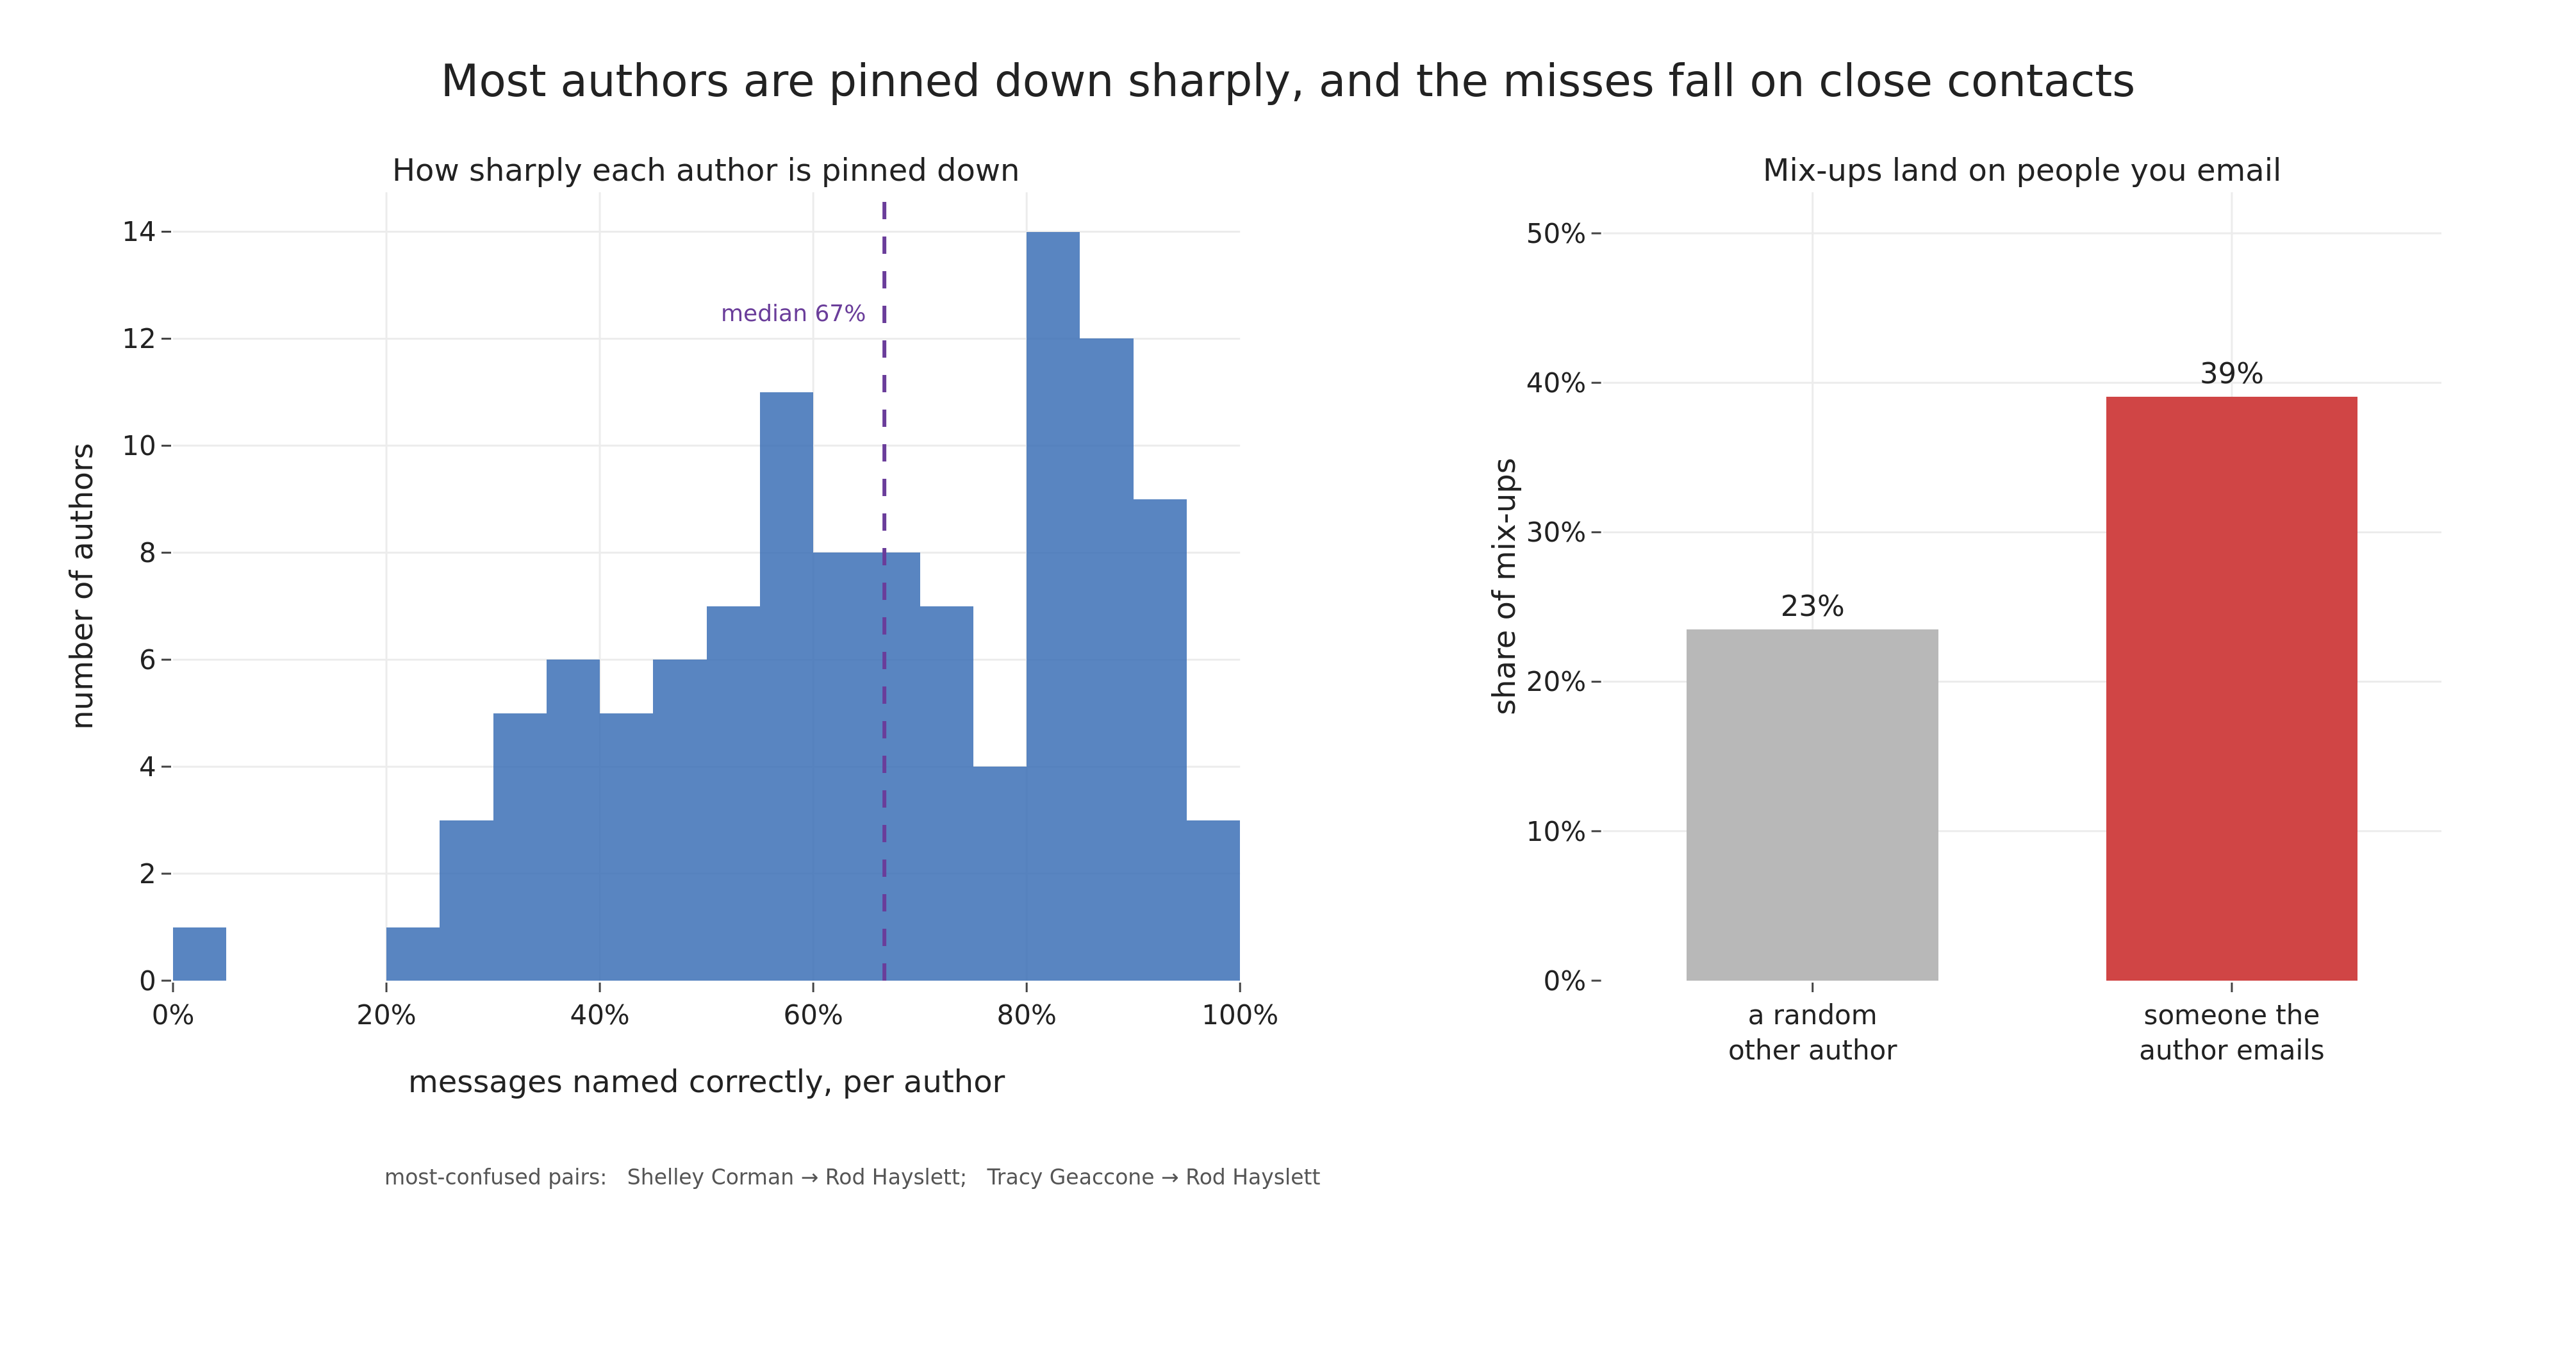

In [5]:
# per-author accuracy on the test split, and where the mix-ups land
per_author = pd.Series(cf, index=yte).groupby(level=0).mean()
classes_set = set(classes)
snd = m[m.sender_person.isin(classes_set)][["message_id", "sender_person"]]
edges = rcp.merge(snd, on="message_id")
edges = edges[edges.recipient_person.isin(classes_set) & (edges.recipient_person != edges.sender_person)]
corr = collections.defaultdict(set)
for s, r in edges[["sender_person", "recipient_person"]].itertuples(index=False):
    corr[s].add(r); corr[r].add(s)
ei = np.where(pred_f != yte)[0]
obs = np.mean([pred_f[i] in corr[yte[i]] for i in ei])
exp = np.mean([len(corr[yte[i]]) / (len(classes) - 1) for i in ei])
pairs = collections.Counter((yte[i], pred_f[i]) for i in ei)
print(f"per-author accuracy: median {per_author.median():.2f}, range {per_author.min():.2f}-{per_author.max():.2f}")
print(f"mix-ups landing on a correspondent: observed {obs:.0%}, expected {exp:.0%}")
print("top confused pairs:", [(NAME.get(a, a), NAME.get(b, b), n) for (a, b), n in pairs.most_common(6)])

fig = make_subplots(rows=1, cols=2, column_widths=[0.56, 0.44], horizontal_spacing=0.16,
    subplot_titles=["How sharply each author is pinned down", "Mix-ups land on people you email"])
fig.add_trace(go.Histogram(x=per_author.values * 100, nbinsx=22, marker_color=BLUE, opacity=0.85,
    showlegend=False), row=1, col=1)
ymax = float(np.histogram(per_author.values * 100, bins=22)[0].max())
fig.add_vline(x=per_author.median() * 100, line=dict(color=PURPLE, dash="dash", width=2), row=1, col=1)
fig.add_annotation(x=per_author.median() * 100 - 1.5, y=ymax * 0.96, xanchor="right", showarrow=False,
    text=f"median {per_author.median():.0%}", font=dict(size=12, color=PURPLE), row=1, col=1)
fig.update_xaxes(title_text="messages named correctly, per author", ticksuffix="%", row=1, col=1)
fig.update_yaxes(title_text="number of authors", row=1, col=1)
fig.add_trace(go.Bar(x=["a random<br>other author", "someone the<br>author emails"],
    y=[exp * 100, obs * 100], marker_color=[GREY, RED], width=0.6,
    text=[f"{exp*100:.0f}%", f"{obs*100:.0f}%"], textposition="outside", textfont=dict(size=15),
    cliponaxis=False, showlegend=False), row=1, col=2)
fig.update_yaxes(title_text="share of mix-ups", range=[0, max(obs, exp) * 135], ticksuffix="%", row=1, col=2)
ex = [f"{NAME.get(a,a)} → {NAME.get(b,b)}" for (a, b), _ in pairs.most_common(2)]
fig.add_annotation(xref="paper", yref="paper", x=0.30, y=-0.27, xanchor="center", showarrow=False,
    text="most-confused pairs:   " + ";   ".join(ex), font=dict(size=11, color="#555"))
fig.update_layout(title="Most authors are pinned down sharply, and the misses fall on close contacts")
save_fig(fig, "a3_confusion.png", w=1340, h=700, margin=dict(l=90, r=70, t=100, b=190))

Most authors are pinned down sharply: the per-author rates pile up well above
half, with a thin tail of people whose writing blends into the crowd. When the
model slips, it does not slip at random. A mix-up lands on someone the true author
actually emails far more often than a random pairing would, and the most-confused
pairs are colleagues who share desks and threads. People who work together write to
the same people about the same things in the same register, and that is exactly
where one identity shades into another.

## What this adds

Pointed at identity, the fusion behaves differently from the rank version, and the
contrast is the point. For rank, the two windows were complementary and roughly
even, and joining them mattered. For identity, the words dominate, naming the
author of a message dozens of times better than chance on a leak-guarded split,
and most of that survives blanking out the signature, so it is genuine style and
not just a name at the foot of the mail. The envelope is a weak author signal
alone, yet it is not redundant: blended in at a modest weight it still fixes more
messages than it breaks, keying on the reach and length a person habitually uses.
And the residual errors are structured, falling on the colleagues a person actually
corresponds with. What you write says who you are; how you send it adds a quiet,
real second voice.